In [33]:
import os
import geopandas as gpd
import requests
import zipfile
import xarray as xr
import xvec
import dask
import json

In [2]:
gmw_url = "https://zenodo.org/records/12756047/files/gmw_mng_2020_v4019_gtiff.zip?download=1"
gmw_local_zip = "in/gmw_latest.zip"
gmw_local_dir = "in/gmw_latest"

gmw_local_dir_0_01 = "in/gmw_latest_0.01_nearest"

In [ ]:
if not os.path.exists("in/"):
    os.makedirs("in/", exist_ok=True)

if not os.path.exists("out/"):
    os.makedirs("out/", exist_ok=True)

print(f"Downloading Global Mangrove Watch data...")
response = requests.get(gmw_url)

with open(gmw_local_zip, "wb") as f:
    print(f"Writing to {gmw_local_zip}")
    f.write(response.content)

Writing to in/gmw_latest.zip


In [4]:
print(f"Unzipping {gmw_local_zip} to {gmw_local_dir}")
with zipfile.ZipFile(gmw_local_zip, "r") as zip_ref:
    zip_ref.extractall(gmw_local_dir)

Unzipping in/gmw_latest.zip to in/gmw_latest


In [ ]:
# Using GDAL, warp all geotiffs in the gmw_local_dir to 0.01 degree resolution

gmw_tifs = [f for f in os.listdir(gmw_local_dir) if f.endswith(".tif")]

if not os.path.exists(gmw_local_dir_0_01):
    os.makedirs(gmw_local_dir_0_01, exist_ok=True)

# Print progress while transforing
for i, f in enumerate(gmw_tifs):
    print(f"Transforming {f} ({i+1}/{len(gmw_tifs)})")
    os.system(f"gdalwarp -t_srs EPSG:4326 -tr 0.01 0.01 -r nearest {gmw_local_dir}/{f} {gmw_local_dir_0_01}/{f}")
    

In [ ]:
# Build VRT
print("Building VRT...")

# Call bash
os.system(f"bash -c 'gdalbuildvrt {gmw_local_dir_0_01}.vrt {gmw_local_dir_0_01}/*.tif'")

In [ ]:
print("Convert to zarr...")

os.system(f"bash -c 'gdal_translate -of ZARR {gmw_local_dir_0_01}.vrt  {gmw_local_dir_0_01}.zarr'")

In [3]:
# Read in zarr
print("Read in zarr")
gmw = xr.open_zarr(f"{gmw_local_dir_0_01}.zarr")

# rename X and y to x and y (otherwise we hit some bug in xvec)
gmw = gmw.rename({"X": "x", "Y": "y"})

gmw

Read in zarr


<xarray.Dataset> Size: 1GB
Dimensions:                  (x: 36000, y: 7400)
Coordinates:
  * x                        (x) float64 288kB -180.0 -180.0 ... 180.0 180.0
  * y                        (y) float64 59kB 34.99 34.98 34.98 ... -38.98 -39.0
Data variables:
    gmw_latest_0.01_nearest  (y, x) float32 1GB dask.array<chunksize=(7400, 10000), meta=np.ndarray>

# Do zonal statistics across all states

In [4]:
abs_asgs_ste_path = "../../geometries/abs-asgs-edition-3/out/ste2021.parquet"

# Read in ASGS STE
asgs_ste_gdf = gpd.read_parquet(abs_asgs_ste_path)

# Filter out rows without geoms
asgs_ste_gdf = asgs_ste_gdf[asgs_ste_gdf.geometry.notnull()]

asgs_ste_gdf

,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,geometry
0,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,"MULTIPOLYGON (((159.0623 -31.50886, 159.06218 ..."
1,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341..."
2,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,"MULTIPOLYGON (((142.5314 -10.68301, 142.53072 ..."
3,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006..."
4,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961..."
5,6,Tasmania,0,No change,AUS,Australia,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6,"MULTIPOLYGON (((144.60439 -41.01001, 144.60443..."
6,7,Northern Territory,0,No change,AUS,Australia,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7,"MULTIPOLYGON (((133.02818 -10.90839, 133.02982..."
7,8,Australian Capital Territory,0,No change,AUS,Australia,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8,"POLYGON ((149.06239 -35.1591, 149.09134 -35.14..."
8,9,Other Territories,0,No change,AUS,Australia,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9,"MULTIPOLYGON (((167.94747 -29.12757, 167.94748..."


<Axes: >

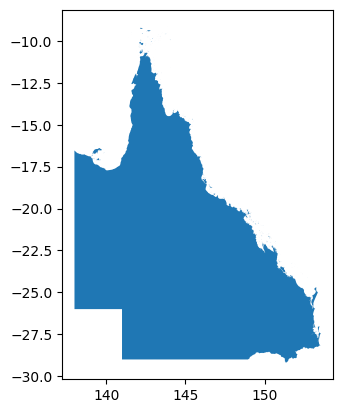

In [5]:
# Plot Queensland
qld_region = asgs_ste_gdf.iloc[[2]]
qld_region.plot()

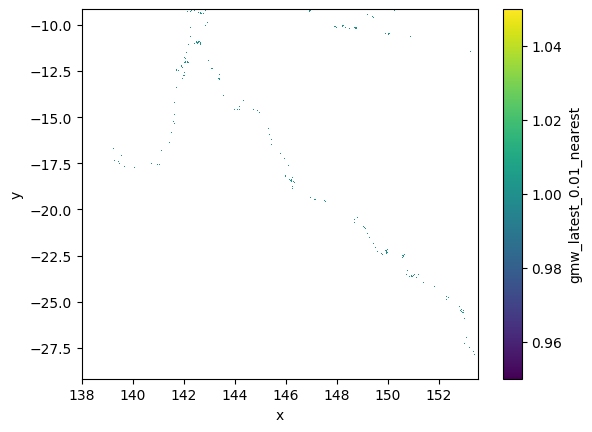

In [6]:
# Take bounds of qld_region and plot
qld_bounds = qld_region.bounds

qld_subset = gmw["gmw_latest_0.01_nearest"].sel(x=slice(qld_bounds.minx.values[0], qld_bounds.maxx.values[0]), y=slice(qld_bounds.maxy.values[0], qld_bounds.miny.values[0]))

qld_subset.plot()

In [7]:
# Look at chunks in zarr file

gmw.chunks

Frozen({'y': (7400,), 'x': (10000, 10000, 10000, 6000)})

In [8]:
# Crop gmw to asgs_ste_gdf bounds

gmw_within_regions = gmw["gmw_latest_0.01_nearest"].sel(x=slice(asgs_ste_gdf.total_bounds[0], asgs_ste_gdf.total_bounds[2]), y=slice(asgs_ste_gdf.total_bounds[3], asgs_ste_gdf.total_bounds[1]))

gmw_within_regions = gmw_within_regions.fillna(0)

In [9]:
gmw_within_regions

<xarray.DataArray 'gmw_latest_0.01_nearest' (y: 2986, x: 7118)> Size: 85MB
dask.array<where, shape=(2986, 7118), dtype=float32, chunksize=(2986, 4800), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) float64 57kB 96.83 96.84 96.84 96.86 ... 168.0 168.0 168.0
  * y        (y) float64 24kB -9.145 -9.155 -9.165 ... -38.98 -38.98 -39.0
Attributes:
    COLOR_INTERPRETATION:  Palette
    _CRS:                  {'wkt': 'GEOGCRS["WGS 84",DATUM["World Geodetic Sy...

In [10]:
aggregated_mean = gmw_within_regions.xvec.zonal_stats(
    asgs_ste_gdf.geometry,
    x_coords="x",
    y_coords="y",
    stats=["mean", ],
    name="asgs_ste",
    index=True
).compute()

In [63]:
aggregated_mean

<xarray.DataArray 'gmw_latest_0.01_nearest' (asgs_ste: 9, zonal_statistics: 1)> Size: 36B
array([[1.2139407e-04],
       [6.5291199e-05],
       [2.0447508e-03],
       [1.0628791e-04],
       [6.4274354e-04],
       [          nan],
       [2.5837615e-03],
       [0.0000000e+00],
       [0.0000000e+00]], dtype=float32)
Coordinates:
  * zonal_statistics  (zonal_statistics) <U4 16B 'mean'
  * asgs_ste          (asgs_ste) object 72B MULTIPOLYGON (((159.0623007527266...
    index             (asgs_ste) int64 72B 0 1 2 3 4 5 6 7 8
Indexes:
    asgs_ste  GeometryIndex (crs=EPSG:4326)
Attributes:
    COLOR_INTERPRETATION:  Palette
    _CRS:                  {'wkt': 'GEOGCRS["WGS 84",DATUM["World Geodetic Sy...

In [12]:
qld_mean = aggregated_mean.values[2][0]
qld_mean

np.float32(0.0020447508)

In [48]:
# Convert back to geodataframe - and merge in geometry values
gdf = aggregated_mean.xvec.to_geodataframe()

gdf = gdf.merge(asgs_ste_gdf, left_on="index", right_index=True)

# Drop geometry column
gdf = gdf.drop(columns=["geometry"])

gdf.to_parquet("out/gmw_mean.parquet")

In [49]:
gdf

,asgs_ste,index,gmw_latest_0.01_nearest,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21
zonal_statistics,,,,,,,,,,,
mean,"MULTIPOLYGON (((159.0623 -31.50886, 159.06218 ...",0,0.000121,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1
mean,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341...",1,0.000065,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2
mean,"MULTIPOLYGON (((142.5314 -10.68301, 142.53072 ...",2,0.002045,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3
mean,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006...",3,0.000106,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4
mean,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961...",4,0.000643,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5
mean,"MULTIPOLYGON (((144.60439 -41.01001, 144.60443...",5,NaN,6,Tasmania,0,No change,AUS,Australia,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6
mean,"MULTIPOLYGON (((133.02818 -10.90839, 133.02982...",6,0.002584,7,Northern Territory,0,No change,AUS,Australia,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7
mean,"POLYGON ((149.06239 -35.1591, 149.09134 -35.14...",7,0.000000,8,Australian Capital Territory,0,No change,AUS,Australia,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8
mean,"MULTIPOLYGON (((167.94747 -29.12757, 167.94748...",8,0.000000,9,Other Territories,0,No change,AUS,Australia,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9


In [56]:
# Write out GeoJSON for each row

features = gdf.iterfeatures()

for i, feature in enumerate(features):
    with open(f"out/{i}.geojson", "w") as f:
        json.dump(feature, f)


# Read in geoparquet to calculate (rough) area of each state

We are expecting

> A total of 0.4 million hectares (45%) is found in Queensland and 0.3 million hectares (39%) are in the Northern Territory

From https://www.agriculture.gov.au/abares/forestsaustralia/australias-forests/profiles/mangrove-2019

The calculation is "rough", as we are using the proportion of pixels that are mangroves in each state to calculate the area of mangroves in each state. This is not perfect, as the area of each pixel is not uniform, and the mangroves are not evenly distributed within each pixel.

In [ ]:
# Read in geoparquet to calculate (rough) area of each state
import geopandas as gpd

gmw_mean = gpd.read_parquet("out/gmw_mean.parquet")

# Multiply columns "AREASQKM21" and "gmw_latest_0.01_nearest" to get rough area of mangroves in each state
gmw_mean["mangrove_area"] = gmw_mean["AREASQKM21"] * gmw_mean["gmw_latest_0.01_nearest"]

gmw_mean

,asgs_ste,index,gmw_latest_0.01_nearest,STE_CODE21,STE_NAME21,CHG_FLAG21,CHG_LBL21,AUS_CODE21,AUS_NAME21,AREASQKM21,LOCI_URI21,mangrove_area
zonal_statistics,,,,,,,,,,,,
mean,"MULTIPOLYGON (((159.0623 -31.50886, 159.06218 ...",0,0.000121,1,New South Wales,0,No change,AUS,Australia,8.007977e+05,http://linked.data.gov.au/dataset/asgsed3/STE/1,97.212087
mean,"MULTIPOLYGON (((146.29286 -39.15778, 146.29341...",1,0.000065,2,Victoria,0,No change,AUS,Australia,2.274962e+05,http://linked.data.gov.au/dataset/asgsed3/STE/2,14.853503
mean,"MULTIPOLYGON (((142.5314 -10.68301, 142.53072 ...",2,0.002045,3,Queensland,0,No change,AUS,Australia,1.730171e+06,http://linked.data.gov.au/dataset/asgsed3/STE/3,3537.769063
mean,"MULTIPOLYGON (((140.66025 -38.06256, 140.66006...",3,0.000106,4,South Australia,0,No change,AUS,Australia,9.842314e+05,http://linked.data.gov.au/dataset/asgsed3/STE/4,104.611900
mean,"MULTIPOLYGON (((117.86953 -35.19108, 117.86961...",4,0.000643,5,Western Australia,0,No change,AUS,Australia,2.526632e+06,http://linked.data.gov.au/dataset/asgsed3/STE/5,1623.976715
mean,"MULTIPOLYGON (((144.60439 -41.01001, 144.60443...",5,NaN,6,Tasmania,0,No change,AUS,Australia,6.801754e+04,http://linked.data.gov.au/dataset/asgsed3/STE/6,NaN
mean,"MULTIPOLYGON (((133.02818 -10.90839, 133.02982...",6,0.002584,7,Northern Territory,0,No change,AUS,Australia,1.348134e+06,http://linked.data.gov.au/dataset/asgsed3/STE/7,3483.257955
mean,"POLYGON ((149.06239 -35.1591, 149.09134 -35.14...",7,0.000000,8,Australian Capital Territory,0,No change,AUS,Australia,2.358133e+03,http://linked.data.gov.au/dataset/asgsed3/STE/8,0.000000
mean,"MULTIPOLYGON (((167.94747 -29.12757, 167.94748...",8,0.000000,9,Other Territories,0,No change,AUS,Australia,2.557420e+02,http://linked.data.gov.au/dataset/asgsed3/STE/9,0.000000


<Axes: >

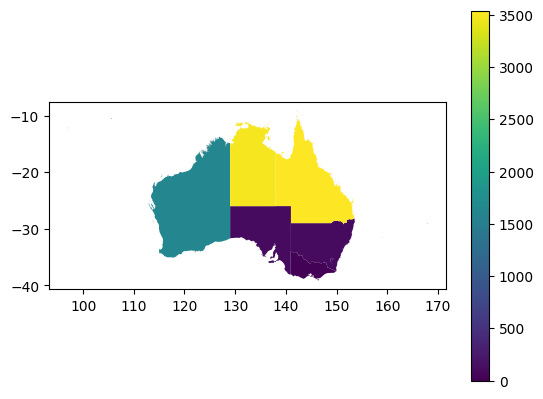

In [64]:
# Plot
gmw_mean.plot(column="mangrove_area", legend=True)